In [1]:
import os, platform

# CPU
print(f"CPUs: {os.cpu_count()}")
print(f"Arch: {platform.machine()}")

# Memory
with open('/proc/meminfo') as f:
    for line in f:
        if line.startswith(('MemTotal', 'MemAvailable')):
            print(f"{line.split(':')[0]}: {int(line.split()[1]) / (1024**2):.1f} GB")

# Disk
stat = os.statvfs('/')
print(f"Disk: {stat.f_bavail * stat.f_frsize / (1024**3):.1f} GB free")

CPUs: 128
Arch: x86_64
MemTotal: 251.5 GB
MemAvailable: 189.1 GB
Disk: 0.1 GB free


In [1]:
# Block 1 — setup + read IPUMS XML schema + read raw .dat
import xml.etree.ElementTree as ET
from pyspark.sql import SparkSession, functions as F

#spark = SparkSession.builder.getOrCreate()

spark = SparkSession.builder \
    .config("spark.driver.memory", "2g") \
    .config("spark.executor.memory", "18g") \
    .config("spark.executor.instances", 7) \
    .getOrCreate()

xml_path = "../evargasnavarro/shared/processed/usa_00001.xml"
dat_path = "../evargasnavarro/shared/processed/usa_00001.dat"

# Parse IPUMS DDI XML for fixed-width specs
ns = {"ddi": "ddi:codebook:2_5"}
root = ET.parse(xml_path).getroot()

specs = []
for var in root.findall(".//ddi:dataDscr/ddi:var", ns):
    loc = var.find("ddi:location", ns)
    fmt = var.find("ddi:varFormat", ns)
    specs.append({
        "name": var.attrib["name"],
        "start": int(loc.attrib["StartPos"]),
        "width": int(loc.attrib["width"]),
        "dcml": int(var.attrib.get("dcml", "0")),
        "type": fmt.attrib.get("type", "character") if fmt is not None else "character"
    })

raw_df = spark.read.text(dat_path)
raw_df.show(5, truncate=False)  # raw fixed-width lines
print(f"Columns in XML spec: {len(specs)}")

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [2]:
# Block 2 — parse to Spark DataFrame + cast numerics + inspect
df = raw_df.select(*[
    F.substring("value", s["start"], s["width"]).alias(s["name"])
    for s in specs
])

for s in specs:
    if s["type"] == "numeric":
        df = df.withColumn(s["name"], F.col(s["name"]).cast("double"))
        if s["dcml"] > 0:
            df = df.withColumn(s["name"], F.col(s["name"]) / (10 ** s["dcml"]))

# readable checks
df.select("YEAR", "STATEFIP", "SEX", "AGE", "RACE", "EDUC", "INCTOT").show(10, truncate=False)
df.printSchema()

+------+--------+---+----+----+----+---------+
|YEAR  |STATEFIP|SEX|AGE |RACE|EDUC|INCTOT   |
+------+--------+---+----+----+----+---------+
|2001.0|1.0     |1.0|39.0|1.0 |3.0 |6400.0   |
|2001.0|1.0     |1.0|33.0|2.0 |10.0|30000.0  |
|2001.0|1.0     |2.0|40.0|1.0 |6.0 |16500.0  |
|2001.0|1.0     |1.0|10.0|1.0 |1.0 |9999999.0|
|2001.0|1.0     |2.0|21.0|1.0 |3.0 |0.0      |
|2001.0|1.0     |1.0|39.0|1.0 |6.0 |21000.0  |
|2001.0|1.0     |2.0|55.0|1.0 |10.0|12000.0  |
|2001.0|1.0     |1.0|38.0|1.0 |3.0 |20000.0  |
|2001.0|1.0     |2.0|32.0|1.0 |2.0 |0.0      |
|2001.0|1.0     |1.0|10.0|1.0 |1.0 |9999999.0|
+------+--------+---+----+----+----+---------+
only showing top 10 rows

root
 |-- YEAR: double (nullable = true)
 |-- SAMPLE: double (nullable = true)
 |-- SERIAL: double (nullable = true)
 |-- CBSERIAL: double (nullable = true)
 |-- NUMPREC: double (nullable = true)
 |-- SUBSAMP: double (nullable = true)
 |-- HHWT: double (nullable = true)
 |-- EXPWTH: double (nullable = true)
 |-- HH

# Data Exploration using Spark

### Number of Columns and Rows

In [ ]:
row_count = df.count()
print("Number of Rows:", row_count)
column_count = len(df.columns)
print("Number of Columns:", column_count)

### Checking for Duplicates

Due to the large size of the dataset, it's difficult to look for duplicate rows on all rows. Instead, we will rely on the PERNUM column which uniquely identifies a person. We will combine this with YEAR (since the same person can respond multiple times across years) to identify potential duplicates. Also, as advised by the IPUMS website: "When combined with SAMPLE and SERIAL, PERNUM uniquely identifies each person within the IPUMS." As a safety precaution, we will use all 4 columns to uniquely identify a person's survey response in order to identify duplicates.

In [ ]:
distinct_counts = df.select(F.countDistinct("YEAR", "PERNUM", "SAMPLE", "SERIAL").alias("unique"))
distinct_counts.show()

In [ ]:
print("Duplicates: {}".format(row_count - distinct_counts.first()[0]))

There are no duplicates.

### Target Columns

From the schema printed above, our columns of interest are "YEAR", "STATEFIP", "SEX", "AGE", "RACE", "EDUC", and "INCTOT". EDUC and INCTOT are the major relavant columns to directly answer our abstract. YEAR will provide chronological information, STATEFIP will provide spatial information, and SEX, AGE, and RACE can provide further data partitioning to reveal trends and patterns on sex, age, and race. 

- YEAR (Numerical): The year the data was collected.
- STATEFIP (Categorical): The US state the data was collected using the FIPS (Federal Information Processing Standards) coding scheme.
- SEX (Categorical): Whether the person was male or female
- AGE (Numerical): The person's age in years.
- RACE (Categorical): The person's race.
- EDUC (Categorical): The person's educational attainment.
- INCTOT (Numerical): The person's pre-tax total personal income (or loss).

All categorical variables have some numeric coding scheme which correspond with qualitative categories. The coding scheme for these variables can be found in the code box below. These coding schemes and descriptions are found on the [IPUMS website](https://usa.ipums.org/usa-action/variables/group).

In [ ]:
statefip = {
    1: "Alabama",
    2: "Alaska",
    4: "Arizona",
    5: "Arkansas",
    6: "California",
    8: "Colorado",
    9: "Connecticut",
    10: "Delaware",
    11: "District of Columbia",
    12: "Florida",
    13: "Georgia",
    15: "Hawaii",
    16: "Idaho",
    17: "Illinois",
    18: "Indiana",
    19: "Iowa",
    20: "Kansas",
    21: "Kentucky",
    22: "Louisiana",
    23: "Maine",
    24: "Maryland",
    25: "Massachusetts",
    26: "Michigan",
    27: "Minnesota",
    28: "Mississippi",
    29: "Missouri",
    30: "Montana",
    31: "Nebraska",
    32: "Nevada",
    33: "New Hampshire",
    34: "New Jersey",
    35: "New Mexico",
    36: "New York",
    37: "North Carolina",
    38: "North Dakota",
    39: "Ohio",
    40: "Oklahoma",
    41: "Oregon",
    42: "Pennsylvania",
    44: "Rhode Island",
    45: "South Carolina",
    46: "South Dakota",
    47: "Tennessee",
    48: "Texas",
    49: "Utah",
    50: "Vermont",
    51: "Virginia",
    53: "Washington",
    54: "West Virginia",
    55: "Wisconsin",
    56: "Wyoming",
    72: "Puerto Rico",
    99: "State not identified"
}
sex = {
    1: "Male", 
    2: "Female", 
    9: "Missing/blank"
}
race = {
    1: "White", 
    2: "Black/African American", 
    3: "American Indian or Alaska Native", 
    4: "Chinese", 
    5: "Japanese", 
    6: "Other Asian or Pacific Islander", 
    7: "Other race, nec", 
    8: "Two major races", 
    9: "Three or more major races"
}
educ = {
    0: "N/A or no schooling", 
    1: "Nursery school to grade 4", 
    2: "Grade 5, 6, 7, or 8", 
    3: "Grade 9", 
    4: "Grade 10", 
    5: "Grade 11", 
    6: "Grade 12", 
    7: "1 year of college", 
    8: "2 years of college", 
    9: "3 years of college", 
    10: "4 years of college", 
    11: "5+ years of college", 
    99: "Missing"
}

In [ ]:
target_columns = ["YEAR", "STATEFIP", "SEX", "AGE", "RACE", "EDUC", "INCTOT"]
df = df.select(target_columns)

### Counting Nulls

In [ ]:
all_null_counts = df.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df.columns])
all_null_counts.show(truncate=False)

We can see that there are no null values in these columns. However, it remains to be seen if the unavailable data defined by the coding schemes (e.g. 99 for EDUC column) are present in the data. This will be known in the next few sections.

### Descriptive statistics for Numeric data

In [ ]:
described = df.select(["YEAR", "AGE", "INCTOT"]).describe()

In [ ]:
described.show(truncate=False)

Our dataset captures survey results between 2001 and 2024. Our age range is between 0 and 97 years old with an average age of approximately 41 years old. Since the maximum age is 97, there are no missing data because the assigned code for missing data is 999. According to the IPUMS website, for our dataset which covers 2001-2024, there are special codes to indicate certain circumstances:

- 0000000 = None
- 0000001 = $1 or break even (2000, 2005-onward ACS and PRCS)
- 9999999 = N/A
- 9999998 = Unknown

I will also check -19998.0 in case that this is a suspicious value.

In [ ]:
income_counts = df.groupBy("INCTOT").count()

In [ ]:
income_counts.filter((F.col("INCTOT") == 9999999.0) |
                    (F.col("INCTOT") == 9999998.0) |
                    (F.col("INCTOT") == 1.0) |
                    (F.col("INCTOT") == 0.0) |
                    (F.col("INCTOT") == -19998.0)
                    ).show()

There are multiple instances of 9999999, indicating missing data. There are no instances of 9999998, and there are a significant number of instances of 0. This is likely a nice round number that survey participants would use to indicate that they had no income that year. To a lesser degree, the same could be said about the number of instaces of 1. The relatively low count of -19998 instances indicate that this is simply a lower bound, though it will be more clear in the plots section.

If we remove the instances of 9999999, the income distribution is:

In [ ]:
df.select("INCTOT").filter(F.col("INCTOT") != 9999999.0).describe().show()

The income distribution appears to be between -19998 and 1945000 dollars with a mean income of 39466.50 dollars.

### Counting Categorical Columns

In [15]:
#While not exactly a categorical column, the year can still act as a category and potentially reveal suspicious values
df.groupBy("YEAR").count().sort("YEAR").show(df.count(), truncate=False)

+------+-------+
|YEAR  |count  |
+------+-------+
|2001.0|1192206|
|2002.0|1074628|
|2003.0|1194928|
|2004.0|1194354|
|2005.0|2878380|
|2006.0|2969741|
|2007.0|2994662|
|2008.0|3000657|
|2009.0|3030728|
|2010.0|3061692|
|2011.0|3112017|
|2012.0|3113030|
|2013.0|3132795|
|2014.0|3132610|
|2015.0|3147005|
|2016.0|3156487|
|2017.0|3190040|
|2018.0|3214539|
|2019.0|3239553|
|2020.0|2641054|
|2021.0|3252599|
|2022.0|3373378|
|2023.0|3405809|
|2024.0|3422888|
+------+-------+



In [16]:
df.groupBy("STATEFIP").count().sort("STATEFIP").show(df.count(), truncate=False)

+--------+-------+
|STATEFIP|count  |
+--------+-------+
|1.0     |1024336|
|2.0     |169583 |
|4.0     |1401893|
|5.0     |625593 |
|6.0     |7764652|
|8.0     |1130393|
|9.0     |764755 |
|10.0    |217185 |
|11.0    |151967 |
|12.0    |4085070|
|13.0    |2048497|
|15.0    |326018 |
|16.0    |369648 |
|17.0    |2704011|
|18.0    |1421822|
|19.0    |718263 |
|20.0    |644038 |
|21.0    |984880 |
|22.0    |949018 |
|23.0    |298374 |
|24.0    |1259877|
|25.0    |1456779|
|26.0    |2154755|
|27.0    |1183607|
|28.0    |657251 |
|29.0    |1316781|
|30.0    |239617 |
|31.0    |433678 |
|32.0    |583505 |
|33.0    |309490 |
|34.0    |1880416|
|35.0    |418393 |
|36.0    |4128739|
|37.0    |2073335|
|38.0    |187329 |
|39.0    |2530318|
|40.0    |795856 |
|41.0    |845684 |
|42.0    |2752179|
|44.0    |248965 |
|45.0    |1017169|
|46.0    |229292 |
|47.0    |1390874|
|48.0    |5304688|
|49.0    |646077 |
|50.0    |164591 |
|51.0    |1747241|
|53.0    |1521890|
|54.0    |420926 |
|55.0    |12

In [17]:
df.groupBy("SEX").count().sort("SEX").show(truncate=False)

+---+--------+
|SEX|count   |
+---+--------+
|1.0|32753559|
|2.0|34372221|
+---+--------+



In [18]:
df.groupBy("RACE").count().sort("RACE").show(truncate=False)

+----+--------+
|RACE|count   |
+----+--------+
|1.0 |50377188|
|2.0 |6582883 |
|3.0 |719191  |
|4.0 |830516  |
|5.0 |181559  |
|6.0 |2437481 |
|7.0 |2900008 |
|8.0 |2834320 |
|9.0 |262634  |
+----+--------+



In [19]:
df.groupBy("EDUC").count().sort("EDUC").show(truncate=False)

+----+--------+
|EDUC|count   |
+----+--------+
|0.0 |4282670 |
|1.0 |5186304 |
|2.0 |4927072 |
|3.0 |1611678 |
|4.0 |1805252 |
|5.0 |1934711 |
|6.0 |19994469|
|7.0 |7857403 |
|8.0 |4113044 |
|10.0|9542074 |
|11.0|5871103 |
+----+--------+



All categorical variables do not have any code scheme defined missing variables. All data points of interest are present.

# Data Plots

Through data visualizations, we analyze the relationship between income and educational attainment, and examine how this relationship varies across key demographic and geographic factors such as gender, race, and state.

In [7]:
import os
os.environ["MPLCONFIGDIR"] = "/tmp/matplotlib"
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()

In [4]:
from pyspark.sql import functions as F

# Remove invalid income values
df_clean = df.filter(
    (F.col("INCTOT") != 9999999.0) & 
    (F.col("INCTOT") != 9999998.0)
)

# Plot-1 Income vs Education

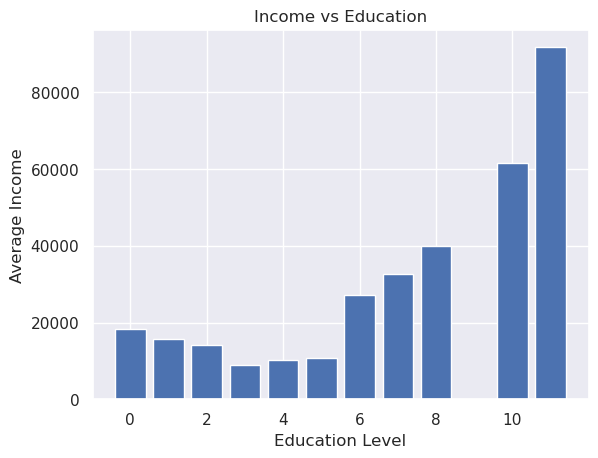

In [15]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

data = (
    df_clean
    .groupBy("EDUC")
    .agg(F.avg("INCTOT").alias("avg_income"))
    .orderBy("EDUC")
    .collect()   # ✅ SAFE (few rows only)
)

x = [row["EDUC"] for row in data]
y = [row["avg_income"] for row in data]

plt.figure()
plt.bar(x, y)
plt.xlabel("Education Level")
plt.ylabel("Average Income")
plt.title("Income vs Education")
plt.show()

# Intepretation

The chart shows a strong positive relationship between education level and average income, where earnings generally increase as education rises. Lower education levels (around 0–5) are associated with relatively low incomes (under ~20k), but there is a noticeable jump starting around mid-level education, and incomes increase sharply at higher levels, reaching above 60k–90k for the highest categories. This suggests that higher education significantly boosts earning potential, with the largest gains occurring at advanced levels rather than early stages of education.

# Plot-2 Income trend over time

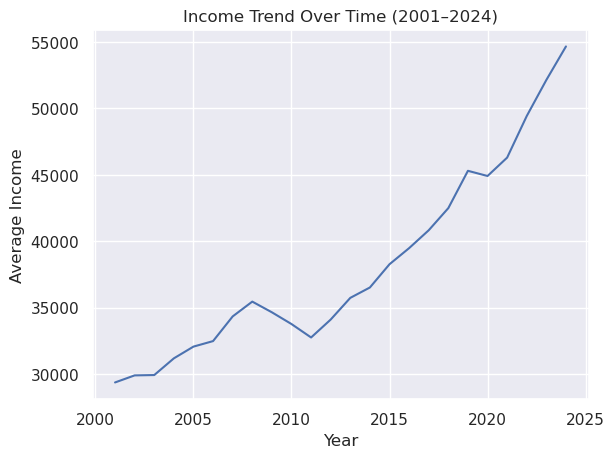

In [16]:
year_income = (
    df_clean
    .groupBy("YEAR")
    .agg(F.avg("INCTOT").alias("avg_income"))
    .orderBy("YEAR")
)

pdf2 = year_income.toPandas()

plt.figure()
plt.plot(pdf2["YEAR"], pdf2["avg_income"])
plt.xlabel("Year")
plt.ylabel("Average Income")
plt.title("Income Trend Over Time (2001–2024)")
plt.show()

# Intepretation

The chart shows a clear long-term upward trend in average income from 2001 to 2024, rising from around 29k to nearly 55k, indicating steady economic growth over time. There is a noticeable dip around 2009–2011, likely reflecting an economic downturn, after which income resumes a consistent upward trajectory. Growth appears to accelerate after about 2015, with especially strong increases in the most recent years, suggesting improving economic conditions or rising wages, although the sharp rise toward the end could also reflect inflation or other external factors rather than purely real income growth

# Plot-3 Income by state(Top 10)

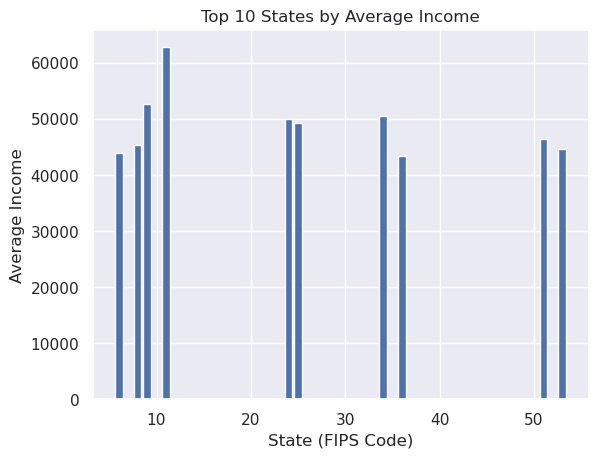

In [8]:
state_income = (
    df_clean
    .groupBy("STATEFIP")
    .agg(F.avg("INCTOT").alias("avg_income"))
    .orderBy(F.desc("avg_income"))
)

pdf3 = state_income.limit(10).toPandas()

plt.figure()
plt.bar(pdf3["STATEFIP"], pdf3["avg_income"])
plt.xlabel("State (FIPS Code)")
plt.ylabel("Average Income")
plt.title("Top 10 States by Average Income")
plt.show()

# Intepretation

The chart shows that among the top 10 states, average income is relatively high but not evenly distributed—one state clearly leads (around ~63k), while the rest cluster in a slightly lower band (~43k–52k). This suggests a small number of states have a stronger concentration of high-paying industries or economic opportunities, creating a noticeable gap even within the top tier. Overall, it highlights that high income in the U.S. is concentrated in a few leading states rather than being uniformly spread across all top performers.

# Plot4 Education vs Income over time

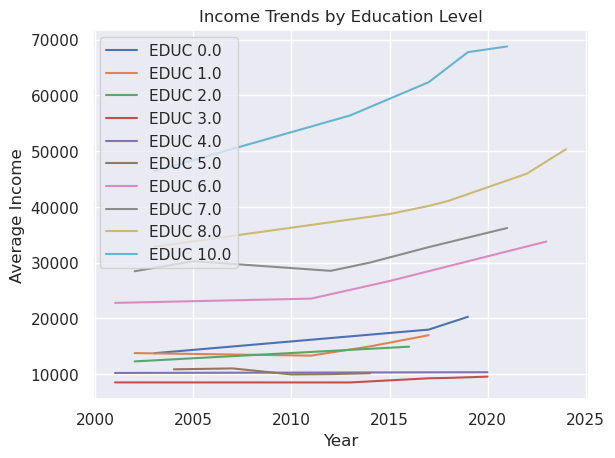

In [15]:
edu_year_income = (
    df_clean
    .groupBy("YEAR", "EDUC")
    .agg(F.avg("INCTOT").alias("avg_income"))
)

pdf4 = edu_year_income.sample(fraction=0.2).toPandas()  # reduce size

plt.figure()

for edu_level in sorted(pdf4["EDUC"].unique())[:10]:  # limit lines
    subset = pdf4[pdf4["EDUC"] == edu_level]
    plt.plot(subset["YEAR"], subset["avg_income"], label=f"EDUC {edu_level}")

plt.xlabel("Year")
plt.ylabel("Average Income")
plt.title("Income Trends by Education Level")
plt.legend()
plt.show()

# Intepretation

The chart shows that average income rises over time for all education levels, but the increase is much stronger at higher levels of education, leading to a widening gap between low- and high-educated groups. Lower education categories (EDUC 0–3) remain in the lower income range (roughly ~8k–17k) with only modest growth, while higher categories (like EDUC 7–10) show steady and much larger increases, reaching significantly higher income levels over time. This highlights that higher education not only leads to higher earnings but also benefits more from economic growth over time. In IPUMS, EDUC values represent attainment levels: for example, EDUC 0 = no schooling/N/A, 1 = elementary (up to ~4th grade), 2 = middle school (5th–8th), 3 = early high school (around 9th grade), meaning these lower codes correspond to relatively low levels of formal education.

# Plot-5   Income by Race

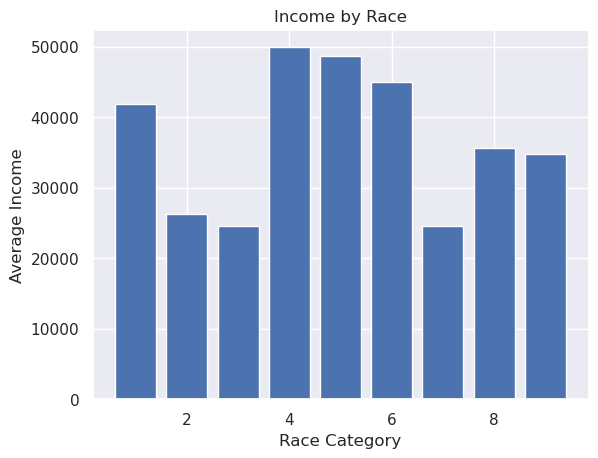

In [13]:
data = (
    df_clean
    .groupBy("RACE")
    .agg(F.avg("INCTOT").alias("avg_income"))
    .orderBy("RACE")
    .collect()
)

x = [r["RACE"] for r in data]
y = [r["avg_income"] for r in data]

plt.bar(x, y)
plt.xlabel("Race Category")
plt.ylabel("Average Income")
plt.title("Income by Race")
plt.show()

# Intepretation

The chart shows noticeable differences in average income across race categories, with some groups earning significantly higher (around ~45k–50k) while others are clustered much lower (around ~24k–27k), indicating clear income disparities across racial groups. A few categories stand out as top earners, while others consistently lag behind, suggesting unequal economic outcomes that may reflect differences in access to education, occupations, or systemic factors. In the IPUMS dataset, race is coded numerically, where common categories include 1 = White, 2 = Black/African American, 3 = American Indian/Alaska Native, 4 = Chinese, 5 = Japanese, 6 = Other Asian or Pacific Islander, 7 = Other race, 8 = Two major races, 9 = Three or more races, meaning each bar represents one of these racial groups rather than a continuous scale.

In [ ]:
# Plot-6 Education vs Income by Gender

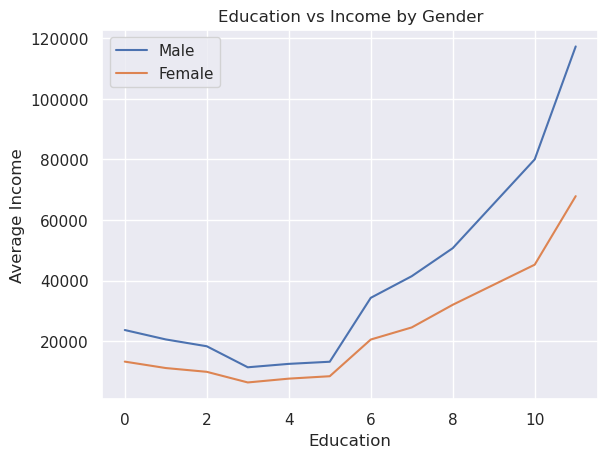

In [14]:
data = (
    df_clean
    .groupBy("EDUC", "SEX")
    .agg(F.avg("INCTOT").alias("avg_income"))
    .collect()
)

# split by sex
male = [(r["EDUC"], r["avg_income"]) for r in data if r["SEX"] == 1]
female = [(r["EDUC"], r["avg_income"]) for r in data if r["SEX"] == 2]

male.sort()
female.sort()

plt.plot([x for x, _ in male], [y for _, y in male], label="Male")
plt.plot([x for x, _ in female], [y for _, y in female], label="Female")

plt.xlabel("Education")
plt.ylabel("Average Income")
plt.title("Education vs Income by Gender")
plt.legend()
plt.show()

# Intepretation

1)The chart shows that income increases with education for both males and females, but males consistently earn more at every education level, and the gap widens as education increases
2)At the highest education levels, the difference becomes substantial, with males reaching much higher incomes than females, indicating that while education boosts earnings for everyone, it also coincides with a growing gender income gap at higher levels.